# Point statistics

The `ps` (point statistics) module provides metrics to compare the mean spatial distribution of transcripts in relation to the centroid and the segmented outline of the cell. The idea of this module is to provide an intuition whether transcripts are distributed unequally, meaning they are more likely to have resulted from a spillover from neighbouring cells. The computed values can either be returned as a dictionary or stored in place in the `spatialdata` object.

**NOTE:** these metrics are still under active development and will change in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import matplotlib.pyplot as plt
import spatialdata as sd
import spatialdata_plot  # noqa
import segtraq
from pathlib import Path

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.__vers

In [3]:
# Load spatial transcriptomics dataset and initalize SegTraQ object
sdata = sd.read_zarr("../../data/xenium.zarr")

# only looking at a subset for visualization purposes
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h
sdata = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)

#initialize SegTraQ object
st = segtraq.SegTraQ(sdata, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid")

no parent found for <ome_zarr.reader.Label object at 0x7ffd44993c90>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffd40739c90>: None
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:1323: UserWarning: Duplicate IDs detected in index 'cell_id' for shapes 'nucleus_boundaries'. Resetting and renaming index to `segtraq_id` to ensure uniqueness.
  nucleus_shapes = _ensure_index(


In [4]:
data_path = Path("/g/huber/projects/CODEX/segtraq/data/20260113_Janesick_Replicate1/xenium")
sdata = sd.read_zarr(data_path / "proseg_output_v3/sdata_proseg_crop.zarr")

st = segtraq.SegTraQ(
    sdata,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:132: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/bl/baseline.py:528: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = geom.area.values


## Centroid mean coordinate difference

To assess the spatial distribution of a gene's transcripts within a cell, we can look at the "center of mass" of the transcripts and compare it to the centroid of the cell. 
The metric can either be computed per gene (as demonstrated below), or for all genes simultaneously (by using the `genes` argument). We compute the euclidean distance between the mean coordinate per transcript $\mu_{x,y}$ with the cell centroid coordinate $cc_{x,y}$ normalised by the cell area $|C|$. The normalisation by cell area is necessary because the computed euclidean distance scales with the cell area.

$$
d_{centroid-mean} = \frac{\sqrt{cc_{x,y}^2-\mu_{x,y}^2}}{|C|}
$$

In [5]:
# for one single gene
st.ps.centroid_mean_coord_diff(restrict_to_within_boundary=True, centroid_region="nucleus")

Processing intersection between cells and nuclei: 100%|██████████| 1533/1533 [00:02<00:00, 513.35it/s]


,cell,distance_norm_all_genes
0,70066,0.063411
1,70069,0.284646
2,70070,0.026450
3,70071,0.092369
4,70072,0.030237
...,...,...
1490,76433,0.035184
1491,76434,0.009633
1492,76435,0.095396
1493,76436,0.115107


In [6]:
sdata["table"].obs["distance_norm_all_genes"].mean()

np.float64(0.053857712829097334)

This result is also stored in `spatialdata` object and accesible in the observations of the `anndata` component.

We can visualise these results in space for the gene ERBB2

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


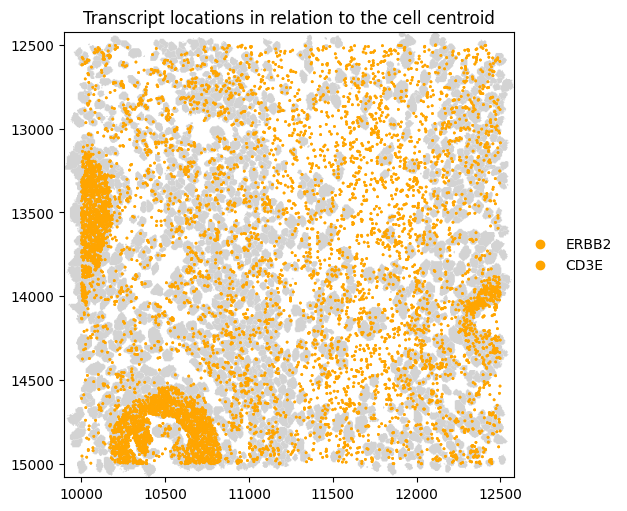

In [7]:
sdata.pl.render_shapes(
    "cell_boundaries",
    color="distance_norm_2_genes",
).pl.render_points(
    "transcripts",
    color="gene",
    groups=["ERBB2", "CD3E"],
    palette=["orange", "orange"],
).pl.show(
    title="Transcript locations in relation to the cell centroid",
    coordinate_systems="global",
    figsize=(10, 5),
)

We notice that there are some cells with a lot of cells at the boundary and some others that are more balanced.

## Distance to membrane

Another way to look at the spatial distribution of transcripts is the distance of a gene's transcripts to the membrane. In some sense, this is complementary to the `centroid_mean_coord_diff` metric. However, in the case of very irregularly shaped cells, the distance to the membrane is a more direct measure of unequal transcript distribution and hence potential spillover.  

The metric is defined as the mean distance to the cell membrane $\mu(d(m,t))$ (as provided in the `spatialdata` object) divided by the cell area $|C|$.
Again, this can be applied either to specific genes or all genes simultaneously.

$$
d_{membrane} = \frac{\mu(d(m,t))}{|C|}
$$

In [21]:
st.ps.distance_to_membrane(restrict_to_within_boundary=True, membrane_region="nucleus", inverse_score=False)

,cell,distance_to_membrane_norm_all_genes
0,70567,0.018171
1,70583,0.084195
2,70498,0.061561
3,70566,0.144144
4,70156,0.095344
...,...,...
1490,72308,0.044311
1491,70834,0.046485
1492,72266,0.028642
1493,72281,0.086340


In [9]:
sdata["table"].obs["distance_to_membrane_norm_ERBB2"].mean()

np.float64(0.10601598027150981)

## Percentage of points in compartments

In [10]:
st.ps.percentage_points_compartments()

,n_total,n_in_cell,n_outside_cell,n_in_nucleus_overlap,n_in_cytoplasm,pct_outside_cell,pct_nucleus,pct_cytoplasm
assignment,,,,,,,,
70026.0,1,0,0,0,0,0.000000,0.000000,0.000000
70066.0,16,11,5,6,5,31.250000,37.500000,31.250000
70067.0,5,3,2,0,3,40.000000,0.000000,60.000000
70068.0,3,0,0,0,0,0.000000,0.000000,0.000000
70069.0,31,20,11,11,9,35.483871,35.483871,29.032258
...,...,...,...,...,...,...,...,...
76434.0,87,74,13,58,16,14.942529,66.666667,18.390805
76435.0,110,91,19,66,25,17.272727,60.000000,22.727273
76436.0,39,33,6,26,7,15.384615,66.666667,17.948718


In [11]:
sdata["table"].obs

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,cell_area,best_nuc_id,IoU,nucleus_fraction,distance_norm_all_genes,distance_to_membrane_norm_ERBB2,pct_outside_cell,pct_nucleus,pct_cytoplasm
70066,70066,78094,2137.753418,2658.982178,0.250000,4,10.00,116.0,1.0,cell_boundaries,29.0,78094.0,0.372469,0.909792,0.063411,NaN,31.250000,37.500000,31.250000
70067,70067,78080,2121.160645,2665.461914,0.372500,5,50.00,288.0,1.0,cell_boundaries,81.0,NaN,NaN,NaN,NaN,NaN,40.000000,0.000000,60.000000
70069,70069,78081,2123.983643,2673.481445,0.338043,7,28.75,214.0,1.0,cell_boundaries,43.0,78081.0,0.621191,0.938538,0.284646,NaN,35.483871,35.483871,29.032258
70070,70070,78084,2129.758057,2670.460205,0.421512,3,32.25,216.0,1.0,cell_boundaries,69.0,78084.0,0.357129,0.969828,0.026450,NaN,15.116279,36.046512,48.837209
70071,70071,78083,2125.497559,2679.595215,0.426923,7,32.50,248.0,1.0,cell_boundaries,40.0,78083.0,0.662761,0.994992,0.092369,NaN,35.294118,55.882353,8.823529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76434,76434,94082,2635.241211,3170.337646,0.458893,7,37.25,266.0,1.0,cell_boundaries,50.0,94082.0,0.601019,0.991662,0.009633,NaN,14.942529,66.666667,18.390805
76435,76435,94078,2654.622314,3156.071777,0.441912,3,85.00,400.0,1.0,cell_boundaries,159.0,94078.0,0.275061,0.914519,0.095396,NaN,17.272727,60.000000,22.727273
76436,76436,94094,2628.212891,3188.504639,0.377793,7,44.75,284.0,1.0,cell_boundaries,80.0,94094.0,0.356451,1.000000,0.115107,NaN,15.384615,66.666667,17.948718
76439,76439,94091,2643.693848,3185.354980,0.370924,7,46.00,292.0,1.0,cell_boundaries,85.0,94091.0,0.306790,1.000000,0.025573,NaN,6.451613,65.591398,27.956989


In [12]:
sdata["nucleus_boundaries"]

,geometry
cell_id,
6327,"POLYGON ((2473.288 2681.75, 2472.225 2682.6, 2..."
6328,"POLYGON ((2470.312 2698.538, 2468.4 2698.962, ..."
6330,"POLYGON ((2482 2746.137, 2480.725 2747.837, 24..."
6331,"POLYGON ((2494.75 3081.675, 2493.9 3082.312, 2..."
6332,"POLYGON ((2486.25 2694.288, 2484.762 2695.988,..."
...,...
95953,"POLYGON ((2594.625 2674.312, 2593.137 2675.375..."
95954,"POLYGON ((2593.137 2653.913, 2591.863 2654.337..."
95955,"POLYGON ((2592.288 2669, 2591.65 2669.85, 2590..."


In [13]:
import pandas as pd

In [14]:
def plot_cell_with_nucleus_and_transcripts(
    cid: float | int, title: str, pix_to_um_scale_factor: float = 0.2125, repositioned_transcripts: bool = False
):
    # add annotation of this cell to .obs
    sdata["table"].obs["focal_cell"] = sdata["table"].obs["cell_id"] == cid

    # compute x,y of cell and nucleus centroids in µm space
    centroid_x_cell = sdata["cell_boundaries"].loc[cid].geometry.centroid.x / pix_to_um_scale_factor
    centroid_y_cell = sdata["cell_boundaries"].loc[cid].geometry.centroid.y / pix_to_um_scale_factor

    nid = sdata["table"].obs.loc[sdata["table"].obs["cell_id"] == cid, "best_nuc_id"].dropna().astype(int)
    centroid_x_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.x / pix_to_um_scale_factor
    centroid_y_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.y / pix_to_um_scale_factor

    # add annotation of this cell to .points and build new `PointsModel``
    trans = sdata.points["transcripts"].compute()
    trans["focal_cell"] = "other_cells"
    trans.loc[trans["cell_id"] == cid, "focal_cell"] = "focal_cell"
    trans["focal_cell"] = trans["focal_cell"].astype("category")
    if repositioned_transcripts:
        trans = trans.drop(columns=["x", "y", "z"])
        trans = trans.rename(columns={"repositioned_x": "x", "repositioned_y": "y", "repositioned_z": "z"})
    sdata.points["transcripts_2"] = sd.models.PointsModel.parse(trans)
    T = sd.transformations.get_transformation(sdata.points["transcripts"])
    sd.transformations.set_transformation(sdata.points["transcripts_2"], T)

    # plot cell and transcripts of that cell
    axes = plt.subplots(1, 1, figsize=(16, 16), constrained_layout=True)[1]

    sdata.pl.render_shapes(
        element="nucleus_boundaries",
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element="cell_boundaries",
        color="focal_cell",
        fill_alpha=0.1,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="blue",
    ).pl.render_points(
        "transcripts_2",
        color="focal_cell",
        fill_alpha=0.1,
        groups=["focal_cell"],
        palette=["red"],
    ).pl.show(
        ax=axes,
        title=title,
        colorbar=True,
        figsize=(10, 10),
    )

    # landmark for cell and nucleus centroid
    axes.scatter([centroid_x_cell], [centroid_y_cell], marker="+", s=400, c="black", linewidths=2, zorder=10, alpha=0.4)
    axes.scatter([centroid_x_nucleus], [centroid_y_nucleus], marker="+", s=400, c="black", linewidths=2, zorder=10)

In [ ]:
plot_cell_with_nucleus_and_transcripts(cid="aphgkeah-1", pix_to_um_scale_factor=1, title="")

We can also plot this metric in space.

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _c

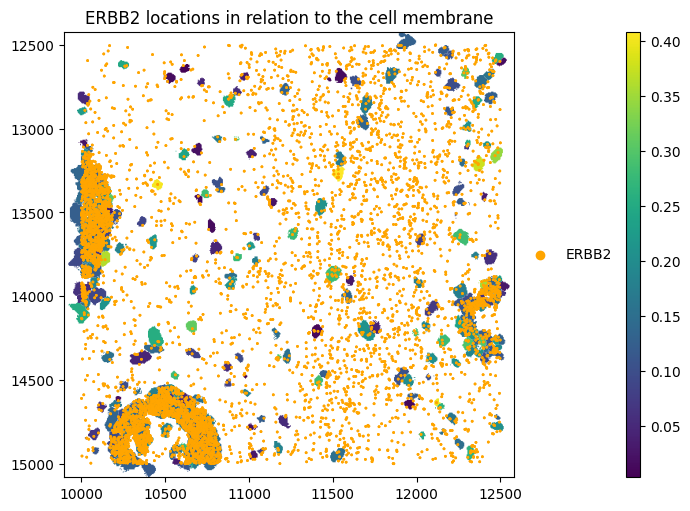

In [ ]:
sdata_plot = copy.deepcopy(sdata)
sdata_plot["table"] = sdata_plot["table"][sdata_plot["table"].obs["distance_to_membrane_norm_ERBB2"].notna()]

sdata_plot.pl.render_shapes(
    "cell_boundaries",
    color="distance_to_membrane_norm_ERBB2",
).pl.render_points(
    "transcripts",
    color="gene",
    groups="ERBB2",
    palette="orange",
).pl.show(
    title="ERBB2 locations in relation to the cell membrane",
    coordinate_systems="global",
    figsize=(10, 5),
)

We note that the two metrics are complementary to each other. However, there are situations with irregularly shaped cells where the distance to the centroid might be very small although the transcripts are clearly on the boarder of the cell.

## Membrane distance skewness

In [16]:
st.ps.membrane_distance_skewness()

,assignment,mean_dist_to_membrane_all_genes,skew_dist_to_membrane_all_genes,n_transcripts_used_all_genes
0,70581.0,4.056405,-0.160923,225
1,70567.0,0.587022,0.661073,39
2,70583.0,2.747174,-0.062729,156
3,70477.0,2.104984,0.485379,185
4,70544.0,2.872890,0.069244,194
...,...,...,...,...
1520,70951.0,NaN,NaN,18
1521,72263.0,NaN,NaN,8
1522,72391.0,NaN,NaN,3
1523,70836.0,NaN,NaN,2


In [23]:
sdata["table"].obs

,cell,original_cell_id,centroid_x,centroid_y,centroid_z,component,volume,surface_area,scale,region,...,best_nuc_id,IoU,nucleus_fraction,distance_norm_all_genes,distance_to_membrane_norm_ERBB2,pct_outside_cell,pct_nucleus,pct_cytoplasm,skew_dist_to_membrane_all_genes,distance_to_membrane_norm_all_genes
70066,70066,78094,2137.753418,2658.982178,0.250000,4,10.00,116.0,1.0,cell_boundaries,...,78094.0,0.372469,0.909792,0.063411,NaN,31.250000,37.500000,31.250000,NaN,0.121358
70067,70067,78080,2121.160645,2665.461914,0.372500,5,50.00,288.0,1.0,cell_boundaries,...,NaN,NaN,NaN,NaN,NaN,40.000000,0.000000,60.000000,NaN,NaN
70069,70069,78081,2123.983643,2673.481445,0.338043,7,28.75,214.0,1.0,cell_boundaries,...,78081.0,0.621191,0.938538,0.284646,NaN,35.483871,35.483871,29.032258,0.288706,0.123946
70070,70070,78084,2129.758057,2670.460205,0.421512,3,32.25,216.0,1.0,cell_boundaries,...,78084.0,0.357129,0.969828,0.026450,NaN,15.116279,36.046512,48.837209,0.416781,0.100741
70071,70071,78083,2125.497559,2679.595215,0.426923,7,32.50,248.0,1.0,cell_boundaries,...,78083.0,0.662761,0.994992,0.092369,NaN,35.294118,55.882353,8.823529,0.075814,0.195753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76434,76434,94082,2635.241211,3170.337646,0.458893,7,37.25,266.0,1.0,cell_boundaries,...,94082.0,0.601019,0.991662,0.009633,NaN,14.942529,66.666667,18.390805,0.028754,0.154404
76435,76435,94078,2654.622314,3156.071777,0.441912,3,85.00,400.0,1.0,cell_boundaries,...,94078.0,0.275061,0.914519,0.095396,NaN,17.272727,60.000000,22.727273,0.211500,0.079699
76436,76436,94094,2628.212891,3188.504639,0.377793,7,44.75,284.0,1.0,cell_boundaries,...,94094.0,0.356451,1.000000,0.115107,NaN,15.384615,66.666667,17.948718,0.179109,0.132104
76439,76439,94091,2643.693848,3185.354980,0.370924,7,46.00,292.0,1.0,cell_boundaries,...,94091.0,0.306790,1.000000,0.025573,NaN,6.451613,65.591398,27.956989,-0.075429,0.118186


<Axes: xlabel='distance_to_membrane_norm_all_genes', ylabel='skew_dist_to_membrane_all_genes'>

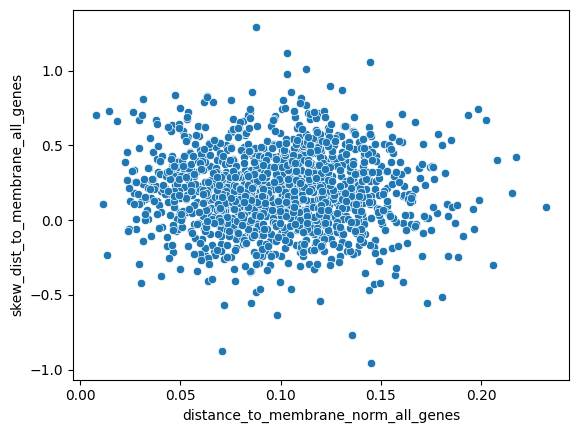

In [24]:
import seaborn as sns
sns.scatterplot(data=sdata["table"].obs, x="distance_to_membrane_norm_all_genes", y="skew_dist_to_membrane_all_genes")